<a href="https://colab.research.google.com/github/TheOGNoticer/Bachelor-Thesis-Machine-Learning-for-IDS/blob/main/Bachelor_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Intrusion Detection System – CICIDS2017

**Bachelor-Thesis: ML-Verfahren in der Cybersecurity**



## 0. Bibliotheken und globale Parameter

In [2]:
# !pip install kagglehub

import re
import glob
import numpy as np
import pandas as pd
import kagglehub

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve,  roc_auc_score, auc,
)

RANDOM_STATE = 42
SAMPLE_SIZE  = 1_000_000

## 1. Daten laden & vorbereiten

In [3]:
path  = kagglehub.dataset_download("dhoogla/cicids2017")
files = glob.glob(path + "/*.parquet")

df_full = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print("Volle Größe:", df_full.shape)


label_col = next(c for c in df_full.columns if c.strip().lower() == "label")
df_full[label_col] = (
    df_full[label_col].astype(str)
    .str.replace(r"[^\x00-\x7F]+", "-", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df_full = df_full.rename(columns={label_col: "Label"})

# Klassen mit weniger als 50 Samples entfernen
class_counts = df_full["Label"].value_counts()
valid_labels = class_counts[class_counts >= 50].index
df_filtered  = df_full[df_full["Label"].isin(valid_labels)].copy()
print("\nNach Entfernen kleiner Klassen:\n", df_filtered["Label"].value_counts())

# Stratifiziertes Sample (erhält die originale Klassenverteilung)
frac = min(1.0, SAMPLE_SIZE / len(df_filtered))
df = (
    df_filtered
    .groupby("Label", group_keys=False)
    .sample(frac=frac, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("\nFinale Sample-Größe:", df.shape)
print(df["Label"].value_counts())

# Duplikate entfernen
before_duplicates = len(df)
df = df.drop_duplicates(ignore_index=True)
after_duplicates = len(df)

print(f"Entfernte Duplikate: {before_duplicates - after_duplicates}")

# Unendliche Werte in fehlende Werte umwandeln
df = df.replace([np.inf, -np.inf], np.nan)

# Anzahl fehlender Werte prüfen
missing_before = df.isna().sum().sum()
rows_before = len(df)

# Listwise Deletion: Zeilen mit fehlenden Werten entfernen
df = df.dropna().reset_index(drop=True)

rows_after = len(df)

print(f"Fehlende Werte vor Bereinigung: {missing_before}")
print(f"Entfernte Zeilen wegen NaN/Inf: {rows_before - rows_after}")
print("Datensatz nach Bereinigung:", df.shape)

# Kopie für das regelbasierte IDS
df_rules = df.copy()

Using Colab cache for faster access to the 'cicids2017' dataset.
Volle Größe: (2313810, 78)

Nach Entfernen kleiner Klassen:
 Label
Benign                      1977318
DoS Hulk                     172846
DDoS                         128014
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
PortScan                       1956
Web Attack - Brute Force       1470
Bot                            1437
Web Attack - XSS                652
Name: count, dtype: int64

Finale Sample-Größe: (999999, 78)
Label
Benign                      854597
DoS Hulk                     74704
DDoS                         55328
DoS GoldenEye                 4446
FTP-Patator                   2563
DoS slowloris                 2327
DoS Slowhttptest              2260
SSH-Patator                   1391
PortScan                       845
Web Attack - Brute Force       635
Bot                

## 2. Label-Encoding, Train/Test-Split & Scaling

In [4]:
le_cic = LabelEncoder().fit(df["Label"])

BENIGN_TEXT  = "Benign" if "Benign" in le_cic.classes_ else df["Label"].mode()[0]
benign_label = le_cic.transform([BENIGN_TEXT])[0]
print(f"Benign-Label: '{BENIGN_TEXT}'  ->  numerisch {benign_label}")
print("Alle Klassen:", list(le_cic.classes_))

df["Label"] = le_cic.transform(df["Label"])





X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTraining: {X_train.shape[0]} | Test: {X_test.shape[0]}")

scaler_cic     = StandardScaler().fit(X_train)
X_train_scaled = scaler_cic.transform(X_train)
X_test_scaled  = scaler_cic.transform(X_test)

# Binäre Wahrheit: 0 = Benign, 1 = Angriff  (für alle Methoden)
true_labels_binary = (y_test.values != benign_label).astype(int)
n_attacks_total    = int(true_labels_binary.sum())
print(f"\nAngriffe im Testset: {n_attacks_total} von {len(true_labels_binary)} Flows")

Benign-Label: 'Benign'  ->  numerisch 0
Alle Klassen: ['Benign', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - XSS']

Training: 784100 | Test: 196026

Angriffe im Testset: 29080 von 196026 Flows


## 3.  Regelbasiertes IDS mit datengetrieben kalibrierten Schwellenwerten



In [5]:
from sklearn.metrics import roc_curve

# ---- robuste Spaltenauflösung (toleriert abweichende Namen) ----
def _norm(s): return re.sub(r"[^a-z0-9]", "", str(s).lower())
_colmap = {_norm(c): c for c in df_rules.columns}
def col(*aliases):
    for a in aliases:
        if _norm(a) in _colmap:
            return _colmap[_norm(a)]
    return None

C = dict(
    dur     = col("Flow Duration"),
    fwd     = col("Total Fwd Packets", "Total Fwd Packet"),
    bwd     = col("Total Backward Packets", "Total Bwd Packets"),
    fwd_len = col("Fwd Packets Length Total", "Total Length of Fwd Packets", "TotLen Fwd Pkts"),
    bwd_len = col("Bwd Packets Length Total", "Total Length of Bwd Packets", "TotLen Bwd Pkts"),
    iat_mean= col("Flow IAT Mean"),
    iat_std = col("Flow IAT Std"),
)
missing = [k for k, v in C.items() if v is None]
assert not missing, f"Fehlende Spalten: {missing} - vorhanden: {list(df_rules.columns)}"

# ---- abgeleitete Flow-Metriken (vektorisiert) ----
def derive(frame):
    dur = frame[C["dur"]].astype("float64").clip(lower=1)     # Mikrosekunden
    fwd = frame[C["fwd"]].astype("float64")
    bwd = frame[C["bwd"]].astype("float64")
    fl  = frame[C["fwd_len"]].astype("float64")
    bl  = frame[C["bwd_len"]].astype("float64")
    out = pd.DataFrame({
        "pps":         (fwd + bwd) / dur * 1e6,
        "bps":         (fl + bl)   / dur * 1e6,
        "avg_fwd_pkt": fl / fwd.clip(lower=1),
        "fwd_count":   fwd,
        "bwd_count":   bwd,
        "total_bytes": fl + bl,
        "iat_cv":      frame[C["iat_std"]].astype("float64")
                       / frame[C["iat_mean"]].astype("float64").clip(lower=1),
    }, index=frame.index)
    return out.replace([np.inf, -np.inf], np.nan).fillna(0.0)

d_all    = derive(df_rules)
FEATURES = ["pps", "bps", "avg_fwd_pkt", "fwd_count", "total_bytes", "iat_cv"]

# ---- Trainingsdaten (keine Test-Leakage) ----
d_train  = d_all.loc[X_train.index]
y_tr_bin = (df_rules.loc[X_train.index, "Label"] != BENIGN_TEXT).astype(int).values

# ---- Diagnose: Benign vs. Angriff je Merkmal ----
print("Trainings-Verteilung (Median) – Benign vs. Angriff:")
for m in FEATURES:
    b = np.median(d_train[m][y_tr_bin == 0]); a = np.median(d_train[m][y_tr_bin == 1])
    pfeil = "Angriff HOCH" if a > b else "Angriff NIEDRIG"
    print(f"  {m:12s} Benign={b:>14,.1f}  Angriff={a:>14,.1f}   -> {pfeil}")

# ---- pro Merkmal: beste Richtung + Schwelle (Youden-J, FPR-gedeckelt) ----
MAX_FPR = 0.15      # max. zugelassene Fehlalarmrate je Einzelregel
MIN_J   = 0.30      # Mindest-Trennkraft, damit ein Merkmal Regel wird

def make_rule(metric, max_fpr=MAX_FPR):
    s = d_train[metric].values
    best = ("none", 0.0, -1.0, 0.0, 0.0)          # (Richtung, Schwelle, J, TPR, FPR)
    for direction, score in (("high", s), ("low", -s)):
        fpr, tpr, thr = roc_curve(y_tr_bin, score)
        J = tpr - fpr
        J[~np.isfinite(thr)] = -1                 # inf-Schwelle ignorieren
        J[fpr > max_fpr]     = -1                 # zu viele Fehlalarme verbieten
        i = int(np.argmax(J))
        if J[i] > best[2]:
            t = float(thr[i] if direction == "high" else -thr[i])
            best = (direction, t, float(J[i]), float(tpr[i]), float(fpr[i]))
    return best

RULES  = {m: make_rule(m) for m in FEATURES}
STRONG = {m: r for m, r in RULES.items() if r[2] >= MIN_J}
assert STRONG, "Keine Regel mit ausreichender Trennkraft – MIN_J senken oder MAX_FPR erhoehen."

# Mehrheitsvotum: ab so vielen anschlagenden Regeln gilt ein Flow als Angriff
# Strikte Mehrheit der verwendeten Regeln
VOTE = max(1, len(STRONG) // 2 + 1)

print(f"\nKalibrierte Regeln (Richtung | Schwelle | J | TPR | FPR), MIN_J={MIN_J}, MAX_FPR={MAX_FPR}:")
for m, r in RULES.items():
    mark = "*" if m in STRONG else " "
    print(f" {mark}{m:12s} {r[0]:4s} thr={r[1]:>14,.1f}  J={r[2]:.3f}  TPR={r[3]:.3f}  FPR={r[4]:.3f}")
print(f"\nVerwendete Regeln: {list(STRONG)}  |  Angriff ab VOTE>={VOTE} anschlagenden Regeln")

# ---- Regelwerk (vektorisiert, richtungsbewusst) ----
def rule_matrix(d):
    R = pd.DataFrame(index=d.index)
    for m, (direction, t, J, tpr, fpr) in STRONG.items():
        R[f"R_{m}"] = ((d[m] >= t) if direction == "high" else (d[m] <= t)).astype(int)
    return R

Trainings-Verteilung (Median) – Benign vs. Angriff:
  pps          Benign=          68.8  Angriff=           0.2   -> Angriff NIEDRIG
  bps          Benign=       4,020.6  Angriff=         138.3   -> Angriff NIEDRIG
  avg_fwd_pkt  Benign=          40.0  Angriff=          34.1   -> Angriff NIEDRIG
  fwd_count    Benign=           2.0  Angriff=           5.0   -> Angriff HOCH
  total_bytes  Benign=         260.0  Angriff=      11,663.0   -> Angriff HOCH
  iat_cv       Benign=           1.6  Angriff=           2.8   -> Angriff HOCH

Kalibrierte Regeln (Richtung | Schwelle | J | TPR | FPR), MIN_J=0.3, MAX_FPR=0.15:
 *pps          low  thr=           0.2  J=0.478  TPR=0.512  FPR=0.034
  bps          low  thr=          10.0  J=0.025  TPR=0.174  FPR=0.149
  avg_fwd_pkt  high thr=       3,491.4  J=0.000  TPR=0.000  FPR=0.000
  fwd_count    high thr=     219,759.0  J=-0.000  TPR=0.000  FPR=0.000
 *total_bytes  high thr=      11,613.0  J=0.653  TPR=0.718  FPR=0.065
 *iat_cv       high thr=      

## 4. ML-Modelle trainieren

In [6]:
# Eigenständig ausgewerteter Random Forest
rf_cic = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# Eigenständig ausgewerteter Decision Tree
dt_cic = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)
dt_cic.fit(X_train_scaled, y_train)


# Modelle innerhalb des VotingClassifiers
dt_voting = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

rf_voting = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Soft Voting kombiniert die Klassenwahrscheinlichkeiten
ensemble_cic = VotingClassifier(
    estimators=[
        ("dt", dt_voting),
        ("rf", rf_voting)
    ],
    voting="soft"
)

# Random Forest separat trainieren
rf_cic.fit(X_train_scaled, y_train)

# VotingClassifier trainiert seine internen Modelle automatisch
ensemble_cic.fit(X_train_scaled, y_train)


VotingClassifier(estimators=[('dt', DecisionTreeClassifier(random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=150,
                                                     n_jobs=-1,
                                                     random_state=42))],
                 voting='soft')

## 5. Vorhersagen und Hybrid-Kombination

In [7]:
# --- 5a. Regelbasiert (nur auf Testdaten) ---
R_test          = rule_matrix(d_all.loc[X_test.index])
rule_score      = R_test.sum(axis=1).values            # Anzahl gefeuerter Regeln (für ROC)
rule_predictions = (rule_score >= VOTE).astype(int)



# --- 5b. KI: Decision Tree (eigenständig) ---
dt_preds        = dt_cic.predict(X_test_scaled)
dt_preds_bin    = (dt_preds != benign_label).astype(int)
benign_idx_dt   = list(dt_cic.classes_).index(benign_label)
dt_proba_attack = 1 - dt_cic.predict_proba(X_test_scaled)[:, benign_idx_dt]


# --- 5b. KI: Random Forest ---
rf_preds       = rf_cic.predict(X_test_scaled)
rf_preds_bin   = (rf_preds != benign_label).astype(int)
benign_idx_rf  = list(rf_cic.classes_).index(benign_label)
rf_proba_attack = 1 - rf_cic.predict_proba(X_test_scaled)[:, benign_idx_rf]

# --- 5c. VotingClassifier ---
ens_preds      = ensemble_cic.predict(X_test_scaled)
ens_preds_bin  = (ens_preds != benign_label).astype(int)
benign_idx_ens = list(ensemble_cic.classes_).index(benign_label)
ens_proba_attack = 1 - ensemble_cic.predict_proba(X_test_scaled)[:, benign_idx_ens]

# --- 5d. Hybrid: Regel ODER ML sagt Angriff (vektorisiert) ---
critical_rule = (R_test.sum(axis=1).values >= VOTE)
hybrid_predictions  = ((critical_rule) | (rf_preds_bin == 1)).astype(int)
hybrid_proba_attack = np.maximum(rf_proba_attack, critical_rule.astype(float))

# --- Regel-Feuer-Statistik ---
print("Wie oft hat jede Regel im Testset gefeuert:")
print(R_test.sum().to_string())

Wie oft hat jede Regel im Testset gefeuert:
R_pps            20400
R_total_bytes    31732
R_iat_cv         45781


## 6. Ergebnisse und Kennzahlen







In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

def evaluate(name, pred, proba):
    pred  = np.asarray(pred)
    truth = true_labels_binary

    tp = int(((pred == 1) & (truth == 1)).sum())
    fp = int(((pred == 1) & (truth == 0)).sum())
    fn = int(((pred == 0) & (truth == 1)).sum())
    tn = int(((pred == 0) & (truth == 0)).sum())

    return {
        "Methode":            name,
        "Geflaggt":           int(pred.sum()),
        "Erkannte Angriffe":  tp,
        "Verpasste Angriffe": fn,
        "Fehlalarme":         fp,
        "Accuracy":           round(accuracy_score(truth, pred), 4),
        "Precision":          round(precision_score(truth, pred, zero_division=0), 4),
        "Recall":             round(recall_score(truth, pred, zero_division=0), 4),
        "F1-Score":           round(f1_score(truth, pred, zero_division=0), 4),
        "AUC":                round(roc_auc_score(truth, proba), 4),
    }

results = pd.DataFrame([
    evaluate("Decision Tree",     dt_preds_bin,       dt_proba_attack),
    evaluate("KI (RandomForest)", rf_preds_bin,       rf_proba_attack),
    evaluate("VotingClassifier",  ens_preds_bin,      ens_proba_attack),
    evaluate("Regelbasiert",      rule_predictions,   rule_score),
    evaluate("Hybrid IDS",        hybrid_predictions, hybrid_proba_attack),
])

print(f"Tatsächliche Anzahl Angriffe im Testset: {n_attacks_total}\n")
print(results.to_string(index=False))

Tatsächliche Anzahl Angriffe im Testset: 29080

          Methode  Geflaggt  Erkannte Angriffe  Verpasste Angriffe  Fehlalarme  Accuracy  Precision  Recall  F1-Score    AUC
    Decision Tree     29090              28967                 113         123    0.9988     0.9958  0.9961    0.9959 0.9978
KI (RandomForest)     28988              28901                 179          87    0.9986     0.9970  0.9938    0.9954 0.9998
 VotingClassifier     29082              28967                 113         115    0.9988     0.9960  0.9961    0.9961 0.9998
     Regelbasiert     29476              19811                9269        9665    0.9034     0.6721  0.6813    0.6767 0.8489
       Hybrid IDS     38657              28905                 175        9752    0.9494     0.7477  0.9940    0.8534 0.9697


### Detaillierte Classification-Reports

In [9]:
for name, pred in [
    ("Decision Tree",      dt_preds_bin),
    ("KI (Random Forest)", rf_preds_bin),
    ("VotingClassifier",   ens_preds_bin),
    ("Regelbasiertes IDS", rule_predictions),
    ("Hybrid IDS",         hybrid_predictions),
]:
    print(f"\n── {name} ──")
    print(classification_report(true_labels_binary, pred,
          target_names=["Benign", "Attack"], zero_division=0))


── Decision Tree ──
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    166946
      Attack       1.00      1.00      1.00     29080

    accuracy                           1.00    196026
   macro avg       1.00      1.00      1.00    196026
weighted avg       1.00      1.00      1.00    196026


── KI (Random Forest) ──
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    166946
      Attack       1.00      0.99      1.00     29080

    accuracy                           1.00    196026
   macro avg       1.00      1.00      1.00    196026
weighted avg       1.00      1.00      1.00    196026


── VotingClassifier ──
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    166946
      Attack       1.00      1.00      1.00     29080

    accuracy                           1.00    196026
   macro avg       1.00      1.00      1.00    196026
wei

## 7. Visualisierungen

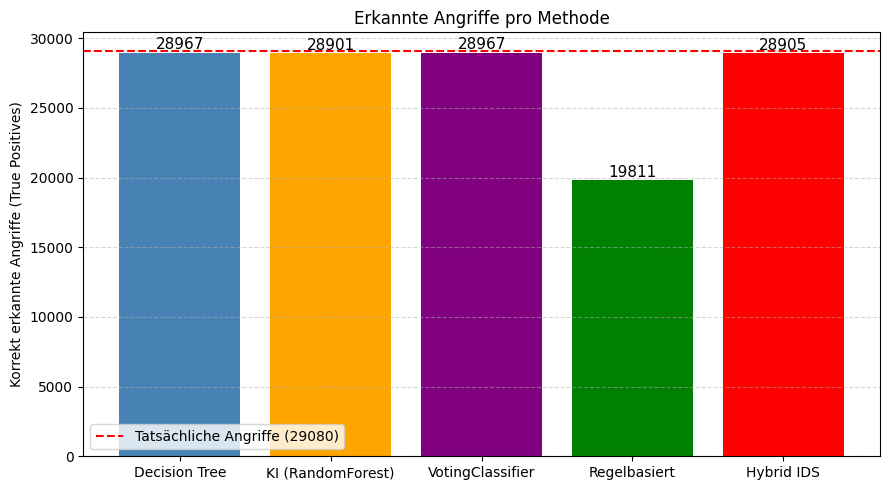

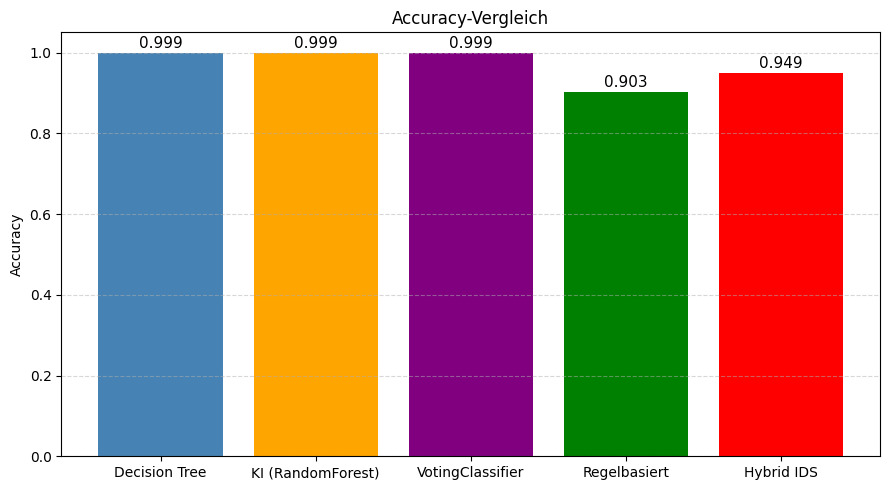

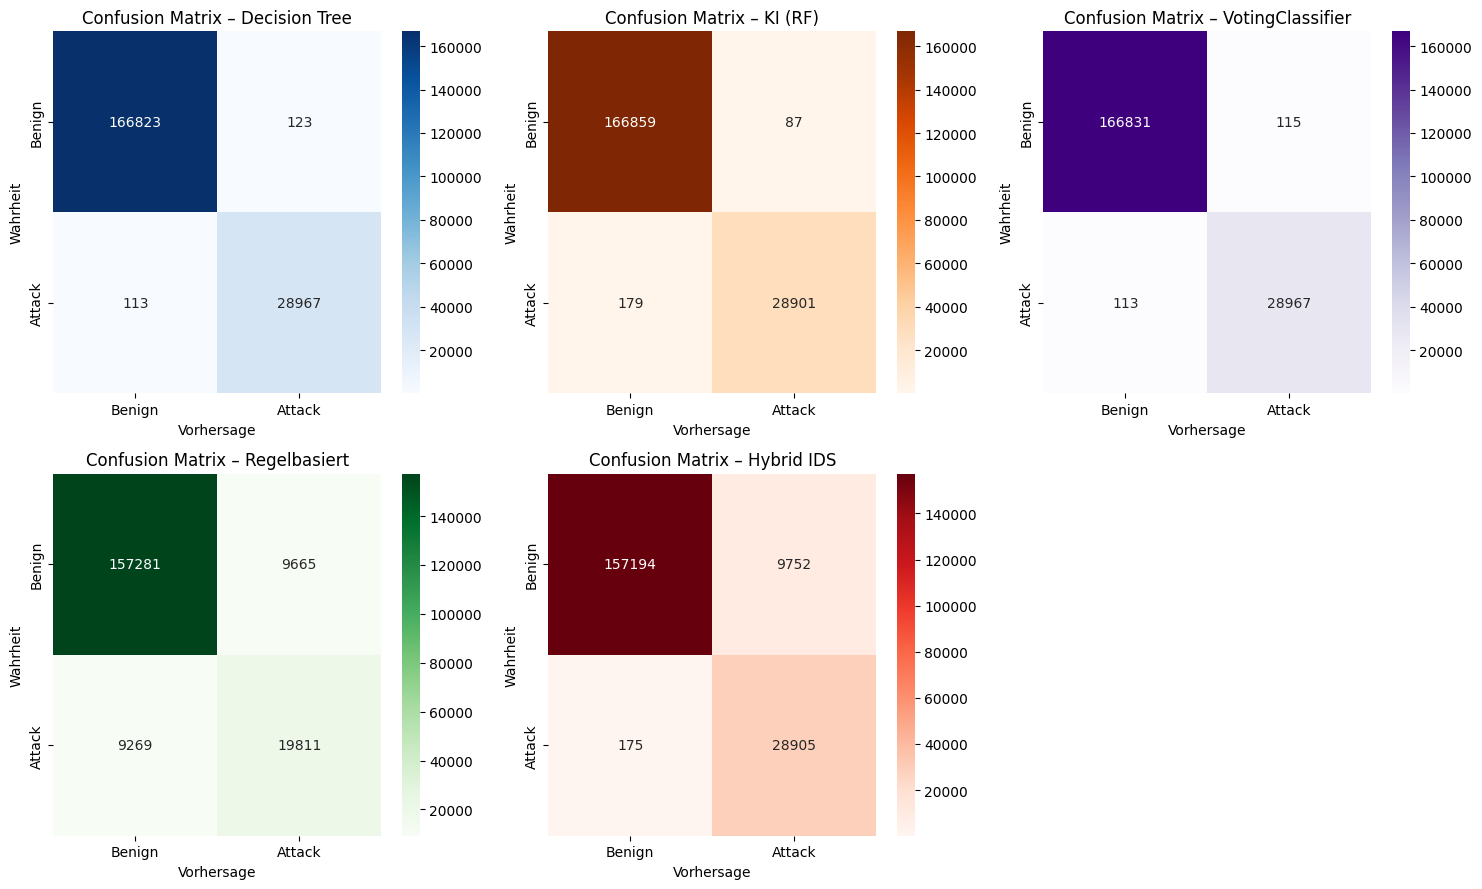

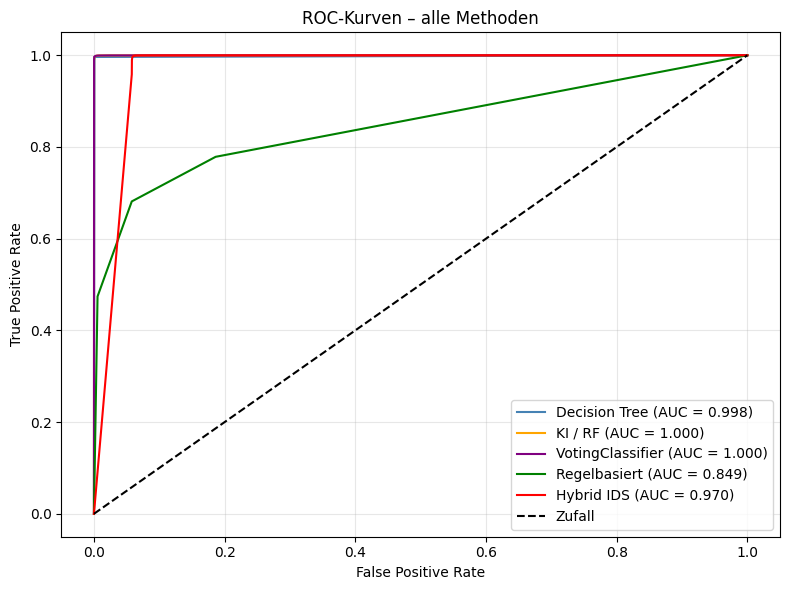

In [10]:
labels_bar = list(results["Methode"])
colors_bar = ["steelblue", "orange", "purple", "green", "red"]  # 5 statt 4 Farben

# --- 7a. Erkannte Angriffe ---
plt.figure(figsize=(9, 5))
bars = plt.bar(labels_bar, results["Erkannte Angriffe"], color=colors_bar)
plt.axhline(n_attacks_total, color="red", linestyle="--",
            label=f"Tatsächliche Angriffe ({n_attacks_total})")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 5,
             f"{int(b.get_height())}", ha="center", va="bottom", fontsize=11)
plt.title("Erkannte Angriffe pro Methode")
plt.ylabel("Korrekt erkannte Angriffe (True Positives)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

# --- 7b. Accuracy ---
plt.figure(figsize=(9, 5))
bars = plt.bar(labels_bar, results["Accuracy"], color=colors_bar)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=11)
plt.title("Accuracy-Vergleich"); plt.ylabel("Accuracy"); plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

# --- 7c. Confusion Matrices ---
cms = [
    (confusion_matrix(true_labels_binary, dt_preds_bin),        "Decision Tree",    "Blues"),
    (confusion_matrix(true_labels_binary, rf_preds_bin),        "KI (RF)",          "Oranges"),
    (confusion_matrix(true_labels_binary, ens_preds_bin),       "VotingClassifier", "Purples"),
    (confusion_matrix(true_labels_binary, rule_predictions),    "Regelbasiert",     "Greens"),
    (confusion_matrix(true_labels_binary, hybrid_predictions),  "Hybrid IDS",       "Reds"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (cm, title, cmap) in zip(axes.flat, cms):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    ax.set_title(f"Confusion Matrix – {title}")
    ax.set_xlabel("Vorhersage"); ax.set_ylabel("Wahrheit")
axes.flat[-1].axis("off")  # überzähliges 6. Feld ausblenden
plt.tight_layout(); plt.show()

# --- 7d. ROC-Kurven (Regel: Anzahl gefeuerter Regeln als Score) ---
roc_data = [
    ("Decision Tree",   dt_proba_attack,     "steelblue"),
    ("KI / RF",         rf_proba_attack,     "orange"),
    ("VotingClassifier",ens_proba_attack,    "purple"),
    ("Regelbasiert",    rule_score,          "green"),
    ("Hybrid IDS",      hybrid_proba_attack, "red"),
]
plt.figure(figsize=(8, 6))
for name, score, color in roc_data:
    fpr, tpr, _ = roc_curve(true_labels_binary, score)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Zufall")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-Kurven – alle Methoden"); plt.legend(loc="lower right")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 8. Feature Importance (Random Forest)

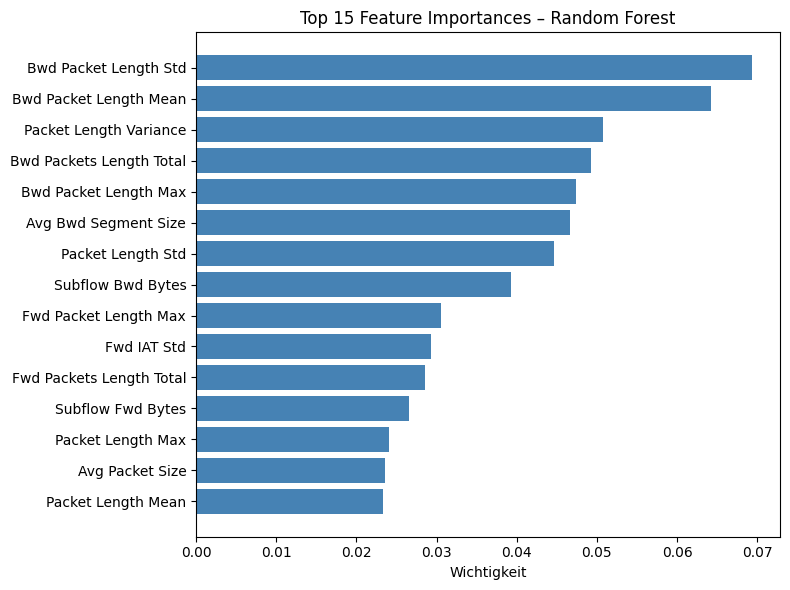

In [11]:
importances = rf_cic.feature_importances_
idx = np.argsort(importances)[-15:]
plt.figure(figsize=(8, 6))
plt.barh(range(len(idx)), importances[idx], color="steelblue")
plt.yticks(range(len(idx)), X.columns[idx])
plt.title("Top 15 Feature Importances – Random Forest")
plt.xlabel("Wichtigkeit"); plt.tight_layout(); plt.show()

## 9. Konsolenausgaben und ROC-Kurven

In [12]:
print("Volle Größe:", df_full.shape)
print("Nach Entfernen kleiner Klassen:", df_filtered.shape)

print(
    f"Entfernte Duplikate: "
    f"{before_duplicates - after_duplicates}"
)

print(
    f"Entfernte Zeilen wegen NaN/Inf: "
    f"{rows_before - rows_after}"
)

Volle Größe: (2313810, 78)
Nach Entfernen kleiner Klassen: (2313742, 78)
Entfernte Duplikate: 19873
Entfernte Zeilen wegen NaN/Inf: 0


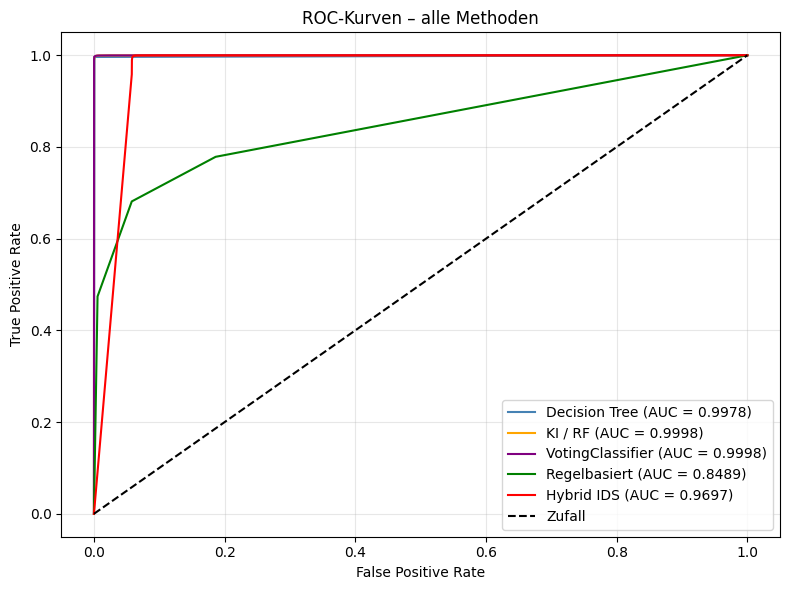

In [13]:
# --- ROC-Kurven aller Methoden ---
roc_data = [
    ("Decision Tree",    dt_proba_attack,     "steelblue"),
    ("KI / RF",          rf_proba_attack,     "orange"),
    ("VotingClassifier", ens_proba_attack,    "purple"),
    ("Regelbasiert",     rule_score,          "green"),
    ("Hybrid IDS",       hybrid_proba_attack, "red"),
]

plt.figure(figsize=(8, 6))

for name, score, color in roc_data:
    fpr, tpr, _ = roc_curve(true_labels_binary, score)
    auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        label=f"{name} (AUC = {auc_value:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Zufall")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-Kurven – alle Methoden")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.1 Confusion Matrices als Einzelabbildungen

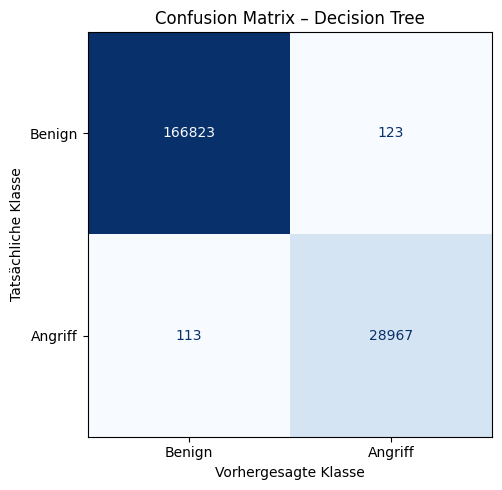

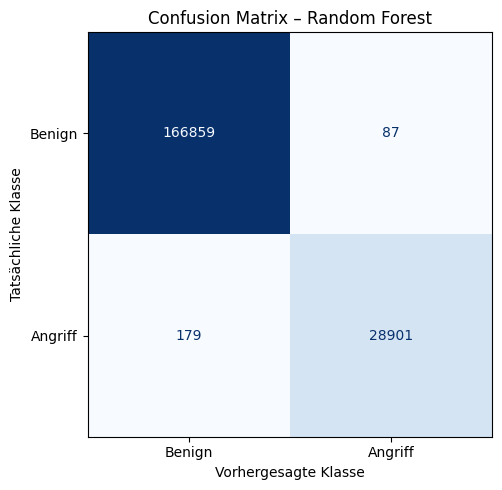

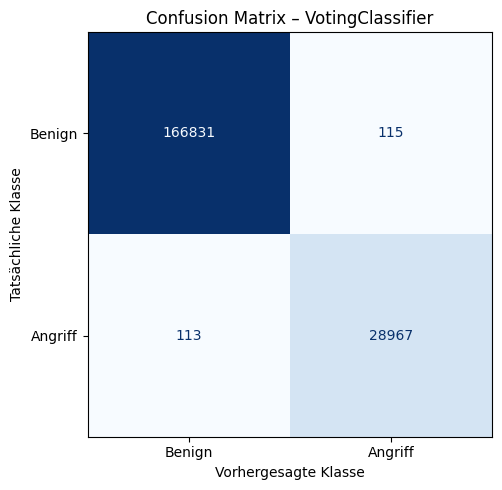

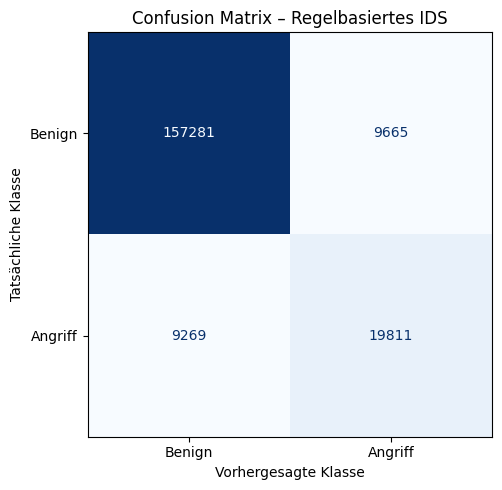

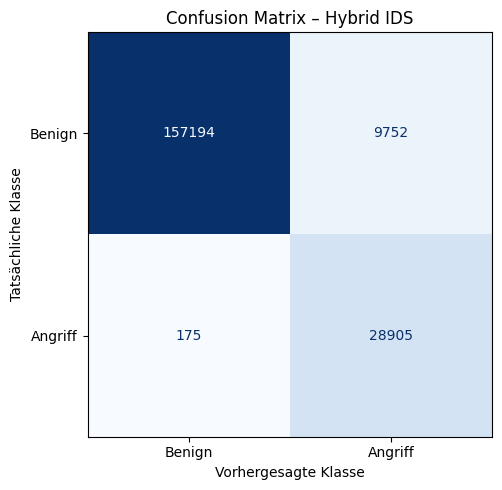

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Modelle und zugehörige binäre Vorhersagen
model_predictions = {
    "Decision Tree": dt_preds_bin,
    "Random Forest": rf_preds_bin,
    "VotingClassifier": ens_preds_bin,
    "Regelbasiertes IDS": rule_predictions,
    "Hybrid IDS": hybrid_predictions
}

# Für jedes Modell eine eigene Confusion Matrix erstellen
for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(
        true_labels_binary,
        predictions,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Angriff"]
    )

    display.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(f"Confusion Matrix – {model_name}")
    ax.set_xlabel("Vorhergesagte Klasse")
    ax.set_ylabel("Tatsächliche Klasse")

    plt.tight_layout()
    plt.show()

## 10. Hyperparameter der eingesetzten Modelle

In [15]:
parameter_table = pd.DataFrame([
    {
        "Modell": "Decision Tree",
        "Parameter": "criterion",
        "Wert": dt_cic.criterion
    },
    {
        "Modell": "Decision Tree",
        "Parameter": "splitter",
        "Wert": dt_cic.splitter
    },
    {
        "Modell": "Decision Tree",
        "Parameter": "max_depth",
        "Wert": dt_cic.max_depth
    },
    {
        "Modell": "Decision Tree",
        "Parameter": "min_samples_split",
        "Wert": dt_cic.min_samples_split
    },
    {
        "Modell": "Decision Tree",
        "Parameter": "min_samples_leaf",
        "Wert": dt_cic.min_samples_leaf
    },
    {
        "Modell": "Decision Tree",
        "Parameter": "class_weight",
        "Wert": dt_cic.class_weight
    },
    {
        "Modell": "Decision Tree",
        "Parameter": "random_state",
        "Wert": dt_cic.random_state
    },

    {
        "Modell": "Random Forest",
        "Parameter": "n_estimators",
        "Wert": rf_cic.n_estimators
    },
    {
        "Modell": "Random Forest",
        "Parameter": "criterion",
        "Wert": rf_cic.criterion
    },
    {
        "Modell": "Random Forest",
        "Parameter": "max_depth",
        "Wert": rf_cic.max_depth
    },
    {
        "Modell": "Random Forest",
        "Parameter": "min_samples_split",
        "Wert": rf_cic.min_samples_split
    },
    {
        "Modell": "Random Forest",
        "Parameter": "min_samples_leaf",
        "Wert": rf_cic.min_samples_leaf
    },
    {
        "Modell": "Random Forest",
        "Parameter": "max_features",
        "Wert": rf_cic.max_features
    },
    {
        "Modell": "Random Forest",
        "Parameter": "bootstrap",
        "Wert": rf_cic.bootstrap
    },
    {
        "Modell": "Random Forest",
        "Parameter": "class_weight",
        "Wert": rf_cic.class_weight
    },
    {
        "Modell": "Random Forest",
        "Parameter": "n_jobs",
        "Wert": rf_cic.n_jobs
    },
    {
        "Modell": "Random Forest",
        "Parameter": "random_state",
        "Wert": rf_cic.random_state
    },

    {
        "Modell": "VotingClassifier",
        "Parameter": "Teilmodelle",
        "Wert": "Decision Tree und Random Forest"
    },
    {
        "Modell": "VotingClassifier",
        "Parameter": "voting",
        "Wert": ensemble_cic.voting
    },
    {
        "Modell": "VotingClassifier",
        "Parameter": "weights",
        "Wert": (
            "Gleichgewichtet"
            if ensemble_cic.weights is None
            else str(ensemble_cic.weights)
        )
    }
])

print(parameter_table.to_string(index=False))

          Modell         Parameter                            Wert
   Decision Tree         criterion                            gini
   Decision Tree          splitter                            best
   Decision Tree         max_depth                            None
   Decision Tree min_samples_split                               2
   Decision Tree  min_samples_leaf                               1
   Decision Tree      class_weight                            None
   Decision Tree      random_state                              42
   Random Forest      n_estimators                             150
   Random Forest         criterion                            gini
   Random Forest         max_depth                            None
   Random Forest min_samples_split                               2
   Random Forest  min_samples_leaf                               1
   Random Forest      max_features                            sqrt
   Random Forest         bootstrap                            

## 11. Diagnosen zur Diskussion




### 11.1 Datensatzstruktur, Duplikate und Merkmalsverteilung

In [16]:
print("Pfad:", path)
print("Dateien:", [f.split('/')[-1] for f in files])
print("Shape gesamt:", df_full.shape)
print("\nSpalten:", list(df_full.columns))

print("\nDuplikate im VOLLEN Datensatz:", df_full.duplicated().sum())
print("Duplikate nach Klassenfilter:", df_filtered.duplicated().sum())
print("Duplikate im Sample:", before_duplicates - after_duplicates)

for f in files:
    d = pd.read_parquet(f)
    print(f"{f.split('/')[-1]:45s} rows={len(d):>9,}  dupes={d.duplicated().sum():>7,}")

print("\nMedian Benign vs. Angriff (Trainingsdaten):")
for m in FEATURES:
    b = np.median(d_train[m][y_tr_bin == 0])
    a = np.median(d_train[m][y_tr_bin == 1])
    print(f"  {m:12s} Benign={b:>16,.2f}  Angriff={a:>16,.2f}")

print("\nKlassenverteilung im Sample:")
print(df_rules["Label"].value_counts())

Pfad: /kaggle/input/cicids2017
Dateien: ['Benign-Monday-no-metadata.parquet', 'Bruteforce-Tuesday-no-metadata.parquet', 'Portscan-Friday-no-metadata.parquet', 'WebAttacks-Thursday-no-metadata.parquet', 'DoS-Wednesday-no-metadata.parquet', 'DDoS-Friday-no-metadata.parquet', 'Infiltration-Thursday-no-metadata.parquet', 'Botnet-Friday-no-metadata.parquet']
Shape gesamt: (2313810, 78)

Spalten: ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',

### 11.2 Flow-Dauer Benign gegenüber Angriff

In [17]:
dur_s = df_rules[C["dur"]] / 1e6
mask_att = (df_rules["Label"] != BENIGN_TEXT)

print("Median Flow-Dauer (s)  Benign:", dur_s[~mask_att].median(),
      " Angriff:", dur_s[mask_att].median())
print("Flows > 100 s   Benign:", (dur_s[~mask_att] > 100).sum(),
      " Angriff:", (dur_s[mask_att] > 100).sum())
print("Flows == 0 s    Benign:", (dur_s[~mask_att] <= 0).sum(),
      " Angriff:", (dur_s[mask_att] <= 0).sum())

# Dauer je Angriffsklasse
print(df_rules.groupby("Label")[C["dur"]].median() / 1e6)

Median Flow-Dauer (s)  Benign: 0.050215499999999996  Angriff: 63.131678
Flows > 100 s   Benign: 57026  Angriff: 11655
Flows == 0 s    Benign: 34  Angriff: 0
Label
Benign                       0.050216
Bot                          0.088911
DDoS                         1.874335
DoS GoldenEye               11.583903
DoS Hulk                    86.353854
DoS Slowhttptest            63.122276
DoS slowloris               99.999276
FTP-Patator                  8.695615
PortScan                     0.000684
SSH-Patator                 12.006304
Web Attack - Brute Force     5.568028
Web Attack - XSS             5.409881
Name: Flow Duration, dtype: float64


### 11.3 Klassenverteilung im vollständigen Datensatz

In [18]:
print(df_filtered["Label"].value_counts())

Label
Benign                      1977318
DoS Hulk                     172846
DDoS                         128014
DoS GoldenEye                 10286
FTP-Patator                    5931
DoS slowloris                  5385
DoS Slowhttptest               5228
SSH-Patator                    3219
PortScan                       1956
Web Attack - Brute Force       1470
Bot                            1437
Web Attack - XSS                652
Name: count, dtype: int64


### 11.4 Flow-Dauer einzelner DoS-Klassen

In [19]:
sl = df_rules.loc[df_rules["Label"]=="DoS slowloris", C["dur"]]/1e6
print(sl.describe())
print("Anteil zwischen 99 und 101 s:", ((sl>99)&(sl<101)).mean())

hulk = df_rules.loc[df_rules["Label"]=="DoS Hulk", C["dur"]]/1e6
print(hulk.describe())

count    2327.000000
mean       59.413512
std        48.891891
min         0.000007
25%         3.002762
50%        99.999276
75%       102.716230
max       119.046064
Name: Flow Duration, dtype: float64
Anteil zwischen 99 und 101 s: 0.11946712505371723
count    74704.000000
mean        76.374896
std         36.842084
min          0.000001
25%         83.704932
50%         86.353854
75%         99.077682
max        119.610756
Name: Flow Duration, dtype: float64


### 11.5 Klassenweiser Recall und Auslöseraten der Einzelregeln

In [20]:
test_labels_text = df_rules.loc[X_test.index, "Label"].values

rows = []
for cls in sorted(pd.unique(test_labels_text)):
    if cls == BENIGN_TEXT: continue
    m = (test_labels_text == cls)
    rows.append({
        "Klasse": cls, "n_Test": int(m.sum()),
        "Regel":  round(rule_predictions[m].mean(), 4),
        "DT":     round(dt_preds_bin[m].mean(), 4),
        "RF":     round(rf_preds_bin[m].mean(), 4),
        "Voting": round(ens_preds_bin[m].mean(), 4),
        "Hybrid": round(hybrid_predictions[m].mean(), 4),
    })
print(pd.DataFrame(rows).sort_values("n_Test", ascending=False).to_string(index=False))

# Welche Einzelregel feuert bei welcher Klasse?
R_cls = R_test.copy()
R_cls["Klasse"] = test_labels_text
print("\n", R_cls.groupby("Klasse").mean().round(3).to_string())

                  Klasse  n_Test  Regel     DT     RF  Voting  Hybrid
                DoS Hulk   14941 0.8675 0.9981 0.9948  0.9981  0.9948
                    DDoS   11066 0.5755 0.9994 0.9991  0.9994  0.9991
           DoS GoldenEye     889 0.3948 0.9978 0.9899  0.9978  0.9921
             FTP-Patator     513 0.0000 0.9961 0.9961  0.9961  0.9961
           DoS slowloris     465 0.0473 0.9957 0.9935  0.9957  0.9935
        DoS Slowhttptest     452 0.2102 0.9624 0.9801  0.9624  0.9823
             SSH-Patator     278 0.0000 0.9892 0.9928  0.9892  0.9928
                PortScan     169 0.0355 0.9349 0.9527  0.9349  0.9527
Web Attack - Brute Force     127 0.0472 0.9921 0.9370  0.9921  0.9370
                     Bot     124 0.0161 0.6774 0.6048  0.6774  0.6129
        Web Attack - XSS      56 0.0000 1.0000 0.9821  1.0000  0.9821

                           R_pps  R_total_bytes  R_iat_cv
Klasse                                                  
Benign                    0.033          0.0

### 11.6 Decision Tree gegenüber VotingClassifier

In [21]:
print("Übereinstimmung DT/Voting:", (dt_preds_bin == ens_preds_bin).mean())
print("Abweichende Flows:", (dt_preds_bin != ens_preds_bin).sum())
print("Anteil DT-Wahrscheinlichkeiten exakt 0 oder 1:",
      ((dt_proba_attack == 0) | (dt_proba_attack == 1)).mean().round(5))
print("Globales Max Flow-Dauer (s):", (df_rules[C["dur"]]/1e6).max())

Übereinstimmung DT/Voting: 0.9999489863589524
Abweichende Flows: 10
Anteil DT-Wahrscheinlichkeiten exakt 0 oder 1: 0.99995
Globales Max Flow-Dauer (s): 119.999993
